In [ ]:
from collections import Counter
from pathlib import Path

import numpy as np

from intrarepresentational_alignment.analysis import (
    analyse_domain_pairs,
    analyse_domain_pairs_conceptnet,
    group_domain_pairs,
)
from intrarepresentational_alignment.data import load_lcc, load_metanet
from intrarepresentational_alignment.embedding import Embedder
from intrarepresentational_alignment.embedding_models import EmbeddingModel
from intrarepresentational_alignment.graph import TopFraction
from intrarepresentational_alignment.similarity import CosineSimilarity, SparseKernel
from intrarepresentational_alignment.viz import (
    plot_cka_bar,
    plot_dense_vs_sparse,
    plot_ged_vs_cka,
    plot_method_detection_table,
    plot_model_comparison_heatmap,
    plot_model_comparison_significance,
    print_alignment_table,
    print_cka_table,
    print_dense_vs_sparse_table,
    print_method_detection_table,
    print_significance_summary,
    print_summary_table,
)

In [ ]:
DATA_PATH      = Path("data/mr-en-20250924142102.rdf")
LCC_PATH       = Path("data/en_small.xml")
MIN_PAIRS      = 8
MAX_PAIRS      = 30
N_PERMS        = 500
EDGE_FRACTION  = 0.15
GED_THRESHOLD  = 0.4
SEED           = 42

## MetaNet


In [3]:
repo = load_metanet(DATA_PATH)
print(f"Loaded  {len(repo.metaphors):,} metaphors, {len(repo.frames):,} frames, "
      f"{len(repo.mappings):,} mappings, {len(repo.examples):,} examples")

http://metanet.english.ubc.ca/metaphor/MetaphorOntology.owl#Closest French frame does not look like a valid URI, trying to serialize this will break.
http://metanet.english.ubc.ca/metaphor/MetaphorOntology.owl#Closest Spanish frame does not look like a valid URI, trying to serialize this will break.
http://metanet.english.ubc.ca/metaphor/MetaphorOntology.owl#Metaphor_Experiential basis does not look like a valid URI, trying to serialize this will break.
http://metanet.english.ubc.ca/metaphor/MetaphorOntology.owl#Related metaphor_Description does not look like a valid URI, trying to serialize this will break.


Loaded  875 metaphors, 951 frames, 645 mappings, 5,616 examples


## LCC Metaphor Corpus


In [4]:
instances = load_lcc(LCC_PATH)
print(f"Loaded {len(instances):,} LCC instances")

all_domain_pairs = group_domain_pairs(instances)
print(f"With explicit source concept (excl. OTHER): {sum(len(v) for v in all_domain_pairs.values()):,} expression pairs")

print(f"Top 15 (source domain -> target domain) pairs:")
pair_counts = Counter({k: len(v) for k, v in all_domain_pairs.items()})
for (src, tgt), n in pair_counts.most_common(15):
    print(f"  {src:<30} -> {tgt:<25} (n={n})")

Loaded 16,265 LCC instances
With explicit source concept (excl. OTHER): 3,336 expression pairs
Top 15 (source domain -> target domain) pairs:
  DISEASE                        -> POVERTY                   (n=43)
  PROTECTION                     -> GUN_RIGHTS                (n=34)
  ABYSS                          -> POVERTY                   (n=22)
  PHYSICAL_LOCATION              -> POVERTY                   (n=22)
  PROTECTION                     -> GUNS                      (n=19)
  STRUGGLE                       -> POVERTY                   (n=18)
  PROTECTION                     -> DEMOCRACY                 (n=18)
  MOVEMENT                       -> CONTROL_OF_GUNS           (n=18)
  PHYSICAL_BURDEN                -> TAXATION                  (n=17)
  MOVEMENT                       -> GOVERNMENT                (n=17)
  MOVEMENT                       -> GUNS                      (n=16)
  ANIMAL                         -> GUNS                      (n=15)
  MOVEMENT                    

## Per-domain CKA experiments


In [ ]:
MODEL_LABELS = {
    EmbeddingModel.WORD2VEC_GOOGLE_NEWS_300: "word2vec-300",
    EmbeddingModel.GLOVE_WIKI_GIGAWORD_50:   "glove-50",
    EmbeddingModel.GLOVE_WIKI_GIGAWORD_100:  "glove-100",
    EmbeddingModel.GLOVE_WIKI_GIGAWORD_300:  "glove-300",
    EmbeddingModel.FASTTEXT_WIKI_NEWS_300:   "fasttext-300",
    EmbeddingModel.CONCEPTNET_NUMBERBATCH_300: "numberbatch-300",
}

selected_pairs = {k: v for k, v in all_domain_pairs.items() if MIN_PAIRS <= len(v) <= MAX_PAIRS}
selected       = sorted(selected_pairs, key=lambda k: len(selected_pairs[k]), reverse=True)
print(f"Domains with {MIN_PAIRS}-{MAX_PAIRS} pairs: {len(selected)}")

all_model_results = {}
for model_id, label in MODEL_LABELS.items():
    print(f"Embedding with {label}...")
    embedder_m = Embedder(model_id)
    all_model_results[label] = analyse_domain_pairs(
        selected_pairs, embedder_m, n_permutations=N_PERMS,
        ged_threshold=GED_THRESHOLD,
        rng=np.random.default_rng(SEED),
    )

# glove-300 is the baseline used for all per-model plots below
embedder       = Embedder(EmbeddingModel.GLOVE_WIKI_GIGAWORD_300)
domain_results = all_model_results["glove-300"]
print_cka_table(domain_results, selected)

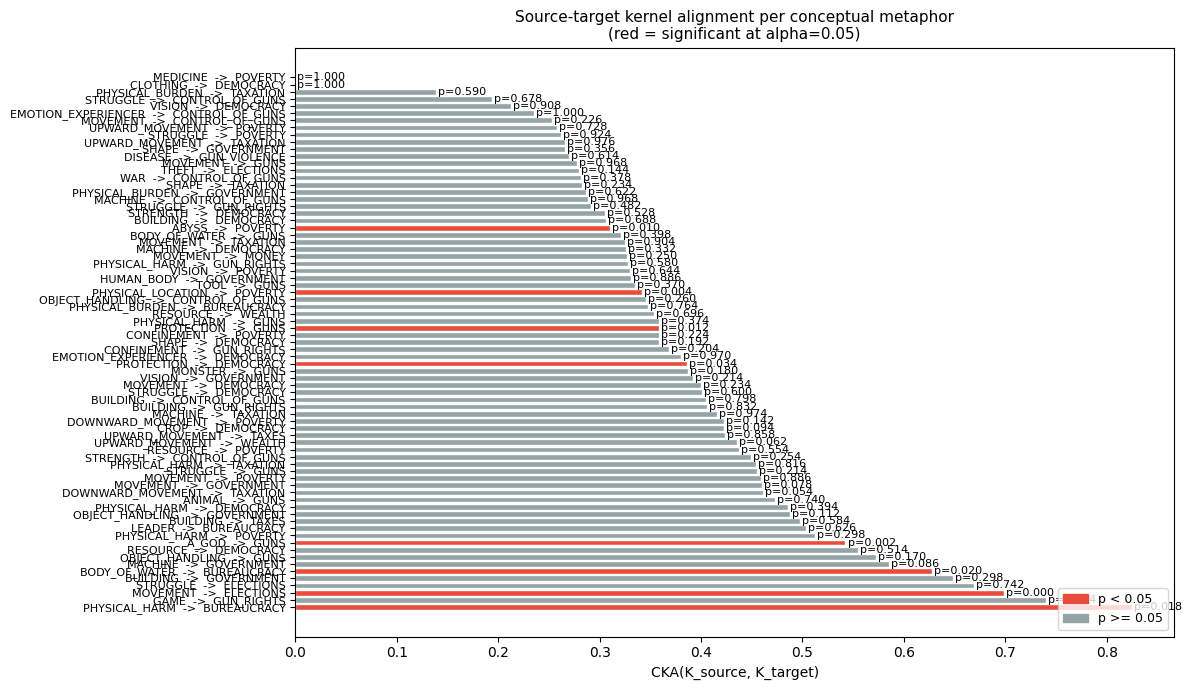

In [ ]:
plot_cka_bar(domain_results)

### Graph distance alignment


In [ ]:
print_alignment_table(domain_results, selected)

Source domain                Target domain             CKA     GED      WL     MCS   p(CKA)   p(GED)   p(WL)   p(MCS)
---------------------------------------------------------------------------------------------------------------------
ABYSS                        POVERTY                 0.311   0.710   0.411   0.773   0.010*   0.960   0.578    1.000 
PHYSICAL_LOCATION            POVERTY                 0.342   0.255   0.180   0.273   0.004*   1.000   1.000    1.000 
PROTECTION                   GUNS                    0.358   0.320   0.229   0.474   0.012*   0.008*  0.684    1.000 
STRUGGLE                     POVERTY                 0.262   0.543   0.261   0.722   0.924    0.996   1.000    0.974 
PROTECTION                   DEMOCRACY               0.386   0.465   0.118   0.556   0.034*   0.972   0.998    0.662 
MOVEMENT                     CONTROL_OF_GUNS         0.253   0.520   0.286   0.444   0.226    0.240   0.970    1.000 
PHYSICAL_BURDEN              TAXATION                0.1

In [ ]:
print_summary_table(domain_results, selected)

Source domain           Target domain              n     CKA   p(CKA)     GED   p(GED)      WL   p(WL)     MCS   p(MCS)
-----------------------------------------------------------------------------------------------------------------------
PHYSICAL_HARM           BUREAUCRACY                8   0.825   0.018*   0.589   0.040*   0.102  0.550    0.250   0.010*
MOVEMENT                ELECTIONS                  9   0.699   0.000*   0.871   0.022*   0.418  0.414    0.667   0.146 
BODY_OF_WATER           BUREAUCRACY                9   0.627   0.020*   0.793   0.050    0.273  0.298    0.556   0.990 
OBJECT_HANDLING         GUNS                       8   0.572   0.170    0.348   0.018*   0.256  0.752    0.625   1.000 
A_GOD                   GUNS                      11   0.542   0.002*   0.726   0.020*   0.376  0.258    0.727   0.964 
PROTECTION              DEMOCRACY                 18   0.386   0.034*   0.465   0.972    0.118  0.998    0.556   0.662 
PROTECTION              GUNS            

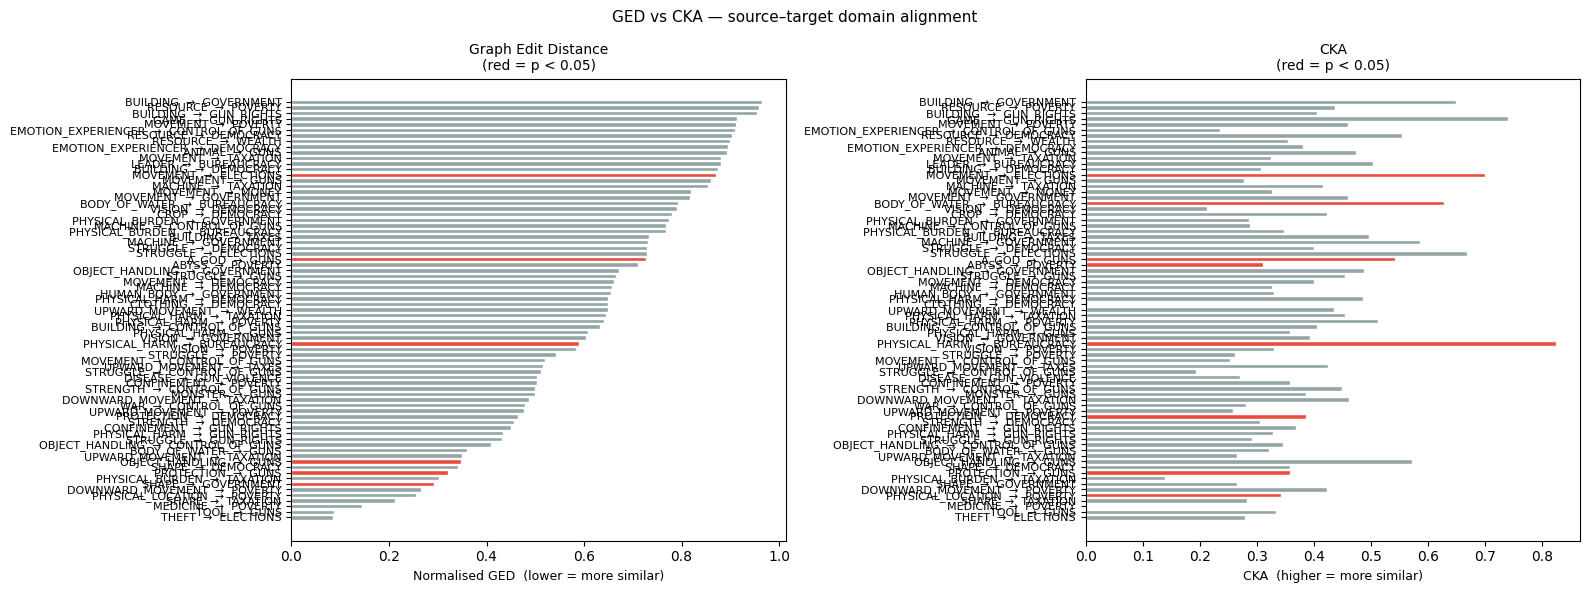

In [ ]:
plot_ged_vs_cka(domain_results)

### Sparse kernel


In [ ]:
sparse_metric  = SparseKernel(CosineSimilarity(), TopFraction(EDGE_FRACTION))
sparse_results = analyse_domain_pairs(
    selected_pairs, embedder, metric=sparse_metric, n_permutations=N_PERMS,
    ged_threshold=GED_THRESHOLD,
    rng=np.random.default_rng(SEED)
)
print_dense_vs_sparse_table(domain_results, sparse_results, selected)

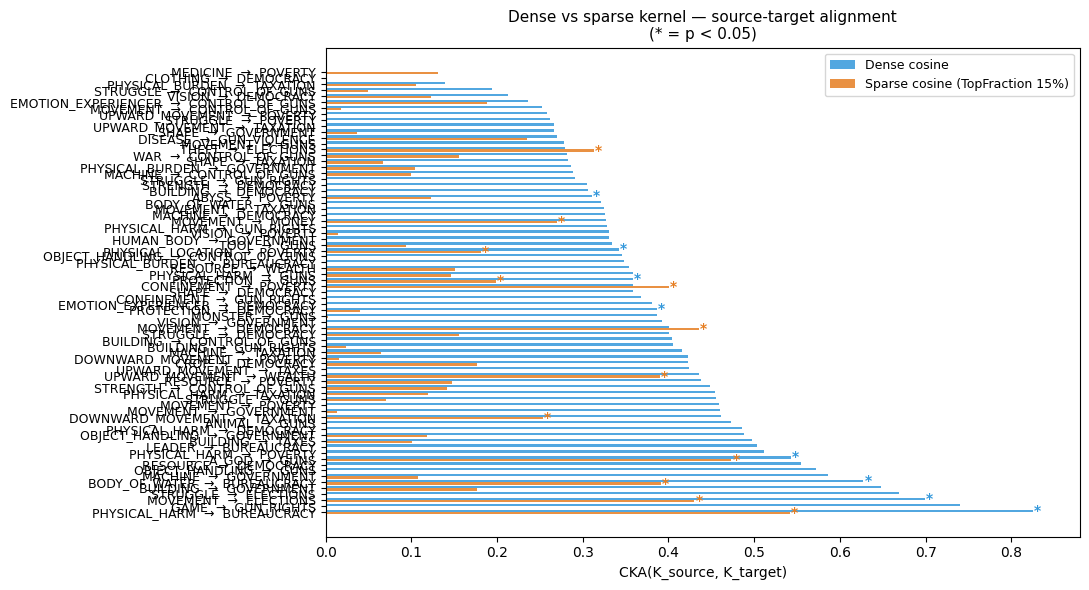

In [ ]:
plot_dense_vs_sparse(domain_results, sparse_results, EDGE_FRACTION)

## Significance summary


In [ ]:
print_significance_summary(domain_results, sparse_results, selected)

CKA identifies significant alignment between 8 metaphor-domain pairs.
Sparse GED identifies 11 significant pairs, 4 of which were previously identified by CKA.
Sparse GED contributes 7 new pairs beyond dense CKA (4 dense-CKA-only; 15 pairs significant by either metric in total).
  GED-only: BUILDING -> GOVERNMENT
  GED-only: CONFINEMENT -> POVERTY
  GED-only: DOWNWARD_MOVEMENT -> TAXATION
  GED-only: MOVEMENT -> DEMOCRACY
  GED-only: PHYSICAL_HARM -> GUNS
  GED-only: THEFT -> ELECTIONS
  GED-only: UPWARD_MOVEMENT -> WEALTH
Metric         Dense      Sparse
--------------------------------
CKA                8 / 75          12 / 75
GED                6 / 75          11 / 75
WL                 1 / 75           4 / 75
MCS                1 / 75           1 / 75
--------------------------------
Any               10 / 75          14 / 75


## Word embedding model comparison

In [ ]:
plot_model_comparison_heatmap(all_model_results, metric="cka")

In [ ]:
plot_model_comparison_significance(all_model_results)

## ConceptNet graph sparsification

Build source- and target-domain kernel matrices from ConceptNet relatedness scores rather than from word embeddings.  For every pair of expressions within a semantic field, the ConceptNet `/relatedness` API is queried; the score becomes the edge weight.  Results are cached to `data/conceptnet_cache.json` so subsequent runs are instant.

In [ ]:
CN_CACHE_PATH = Path("data/conceptnet_cache.json")

print("Querying ConceptNet (new pairs hit the API; cached pairs are instant)...")
conceptnet_results = analyse_domain_pairs_conceptnet(
    selected_pairs,
    n_permutations=N_PERMS,
    ged_threshold=GED_THRESHOLD,
    rng=np.random.default_rng(SEED),
    cache_path=CN_CACHE_PATH,
    verbose=True,
)
print(f"\nConceptNet results: {len(conceptnet_results)} / {len(selected_pairs)} domain pairs had ConceptNet coverage")

# Add to the shared model-results dict so existing comparison plots include it
all_model_results["conceptnet"] = conceptnet_results

In [ ]:
print_summary_table(conceptnet_results, sorted(conceptnet_results))

### Updated model comparison (including ConceptNet)

In [ ]:
plot_model_comparison_heatmap(all_model_results, metric="cka")

In [ ]:
plot_model_comparison_significance(all_model_results)

### Method overlap table

Each cell shows **N (U)** where N = number of significant domain pairs at p < 0.05, and U = number of those pairs detected *only* by that method (not by any other method in the same row).

In [ ]:
print_method_detection_table(all_model_results, cn_key="conceptnet", keys=selected)

In [ ]:
plot_method_detection_table(all_model_results, cn_key="conceptnet", keys=selected)